<a href="https://colab.research.google.com/github/shumailas709/Data-Analytic-Portfolio-/blob/main/Project8_GooglePlayStore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================
# Project 8 - Google Play Store
# Dataset: Android App Market
# Source: Kaggle
# ================================

!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [2]:
# ================================
# Step 1 - Upload Dataset
# ================================

from google.colab import files
uploaded = files.upload()


Saving user_reviews.csv to user_reviews.csv
Saving apps.csv to apps.csv


In [3]:
# ================================
# Step 2 - Load Dataset
# ================================

df_apps = pd.read_csv('apps.csv')
df_reviews = pd.read_csv('user_reviews.csv')

print("Apps Dataset:")
print(f"Shape: {df_apps.shape}")
print(df_apps.head(3))

print("\nReviews Dataset:")
print(f"Shape: {df_reviews.shape}")
print(df_reviews.head(3))


Apps Dataset:
Shape: (9659, 14)
   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   

         Category  Rating  Reviews  Size    Installs  Type Price  \
0  ART_AND_DESIGN     4.1      159  19.0     10,000+  Free     0   
1  ART_AND_DESIGN     3.9      967  14.0    500,000+  Free     0   
2  ART_AND_DESIGN     4.7    87510   8.7  5,000,000+  Free     0   

  Content Rating                     Genres      Last Updated Current Ver  \
0       Everyone               Art & Design   January 7, 2018       1.0.0   
1       Everyone  Art & Design;Pretend Play  January 15, 2018       2.0.0   
2       Everyone               Art & Design    August 1, 2018       1.2.4   

    Android Ver  
0  4.0.3 and up  
1  4.0.3 and up  
2  4.0.3 and up  

Reviews Dataset:
Shape: (64295, 5)
     

In [4]:
# ================================
# Step 3 - Data Cleaning
# ================================

print("Apps Missing Values:")
print(df_apps.isnull().sum())

print("\nReviews Missing Values:")
print(df_reviews.isnull().sum())

# Drop duplicates
df_apps.drop_duplicates(inplace=True)
df_reviews.drop_duplicates(inplace=True)

# Drop nulls
df_apps.dropna(inplace=True)
df_reviews.dropna(subset=['Sentiment'], inplace=True)

# Fix Installs column
df_apps['Installs'] = df_apps['Installs'].str.replace('[+,]', '', regex=True).astype(int)

# Fix Price column
df_apps['Price'] = df_apps['Price'].str.replace('$', '', regex=False).astype(float)

# Fix Rating
df_apps['Rating'] = pd.to_numeric(df_apps['Rating'], errors='coerce')

print("\nCleaning done!")
print(f"Apps shape: {df_apps.shape}")
print(f"Reviews shape: {df_reviews.shape}")


Apps Missing Values:
Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

Reviews Missing Values:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Cleaning done!
Apps shape: (7021, 14)
Reviews shape: (29697, 5)


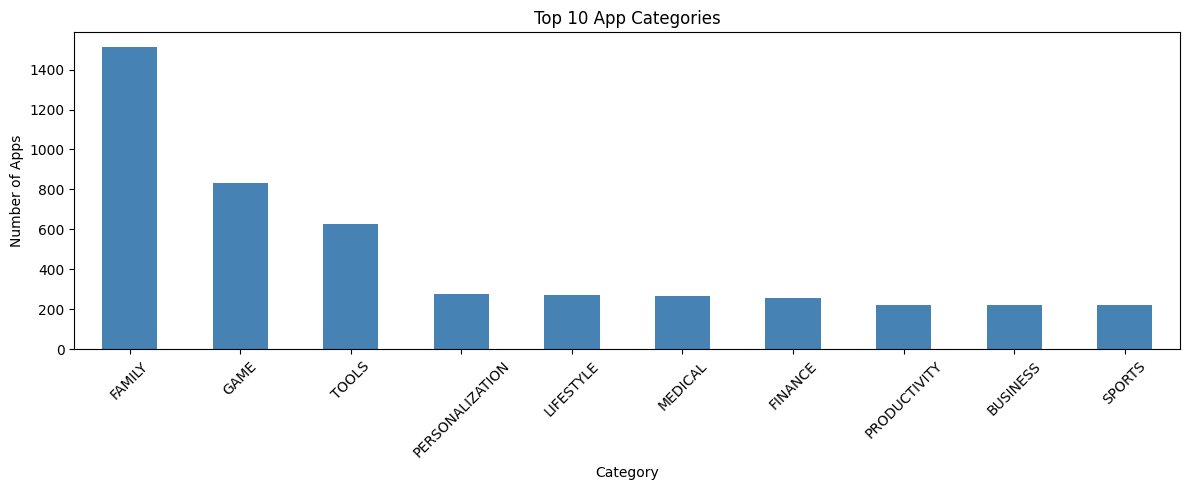

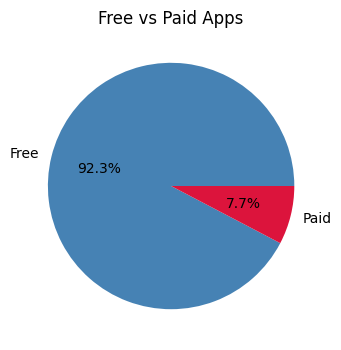

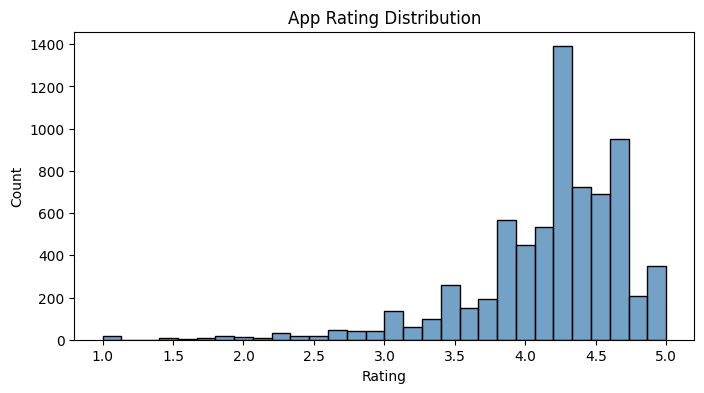

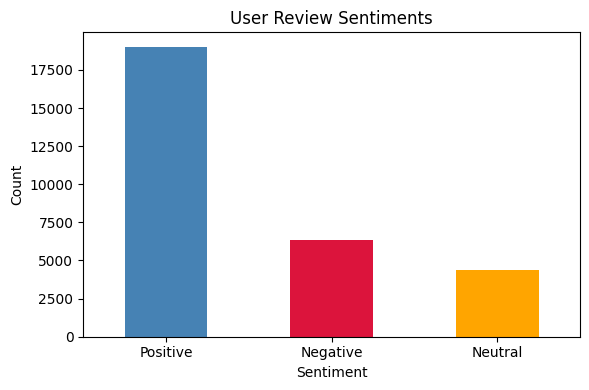

All plots ready!


In [5]:
# ================================
# Step 4 - EDA & Visualizations
# ================================

# Plot 1: Top 10 Categories
plt.figure(figsize=(12, 5))
df_apps['Category'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Free vs Paid
plt.figure(figsize=(5, 4))
df_apps['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                     colors=['steelblue','crimson'])
plt.title('Free vs Paid Apps')
plt.ylabel('')
plt.show()

# Plot 3: Rating Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_apps['Rating'].dropna(), bins=30, color='steelblue')
plt.title('App Rating Distribution')
plt.xlabel('Rating')
plt.show()

# Plot 4: Sentiment Distribution
plt.figure(figsize=(6, 4))
df_reviews['Sentiment'].value_counts().plot(kind='bar',
                                             color=['steelblue','crimson','orange'])
plt.title('User Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("All plots ready!")


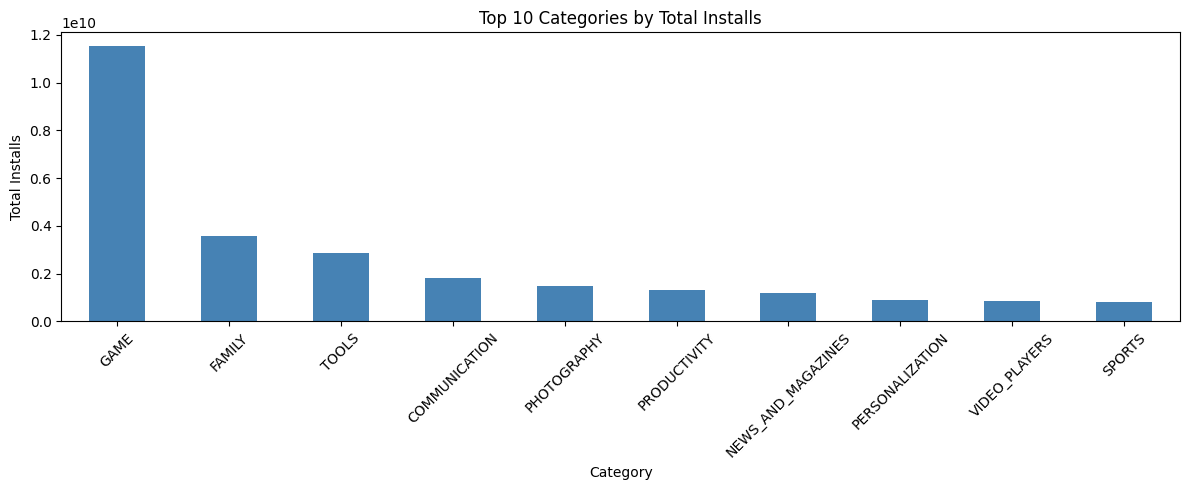

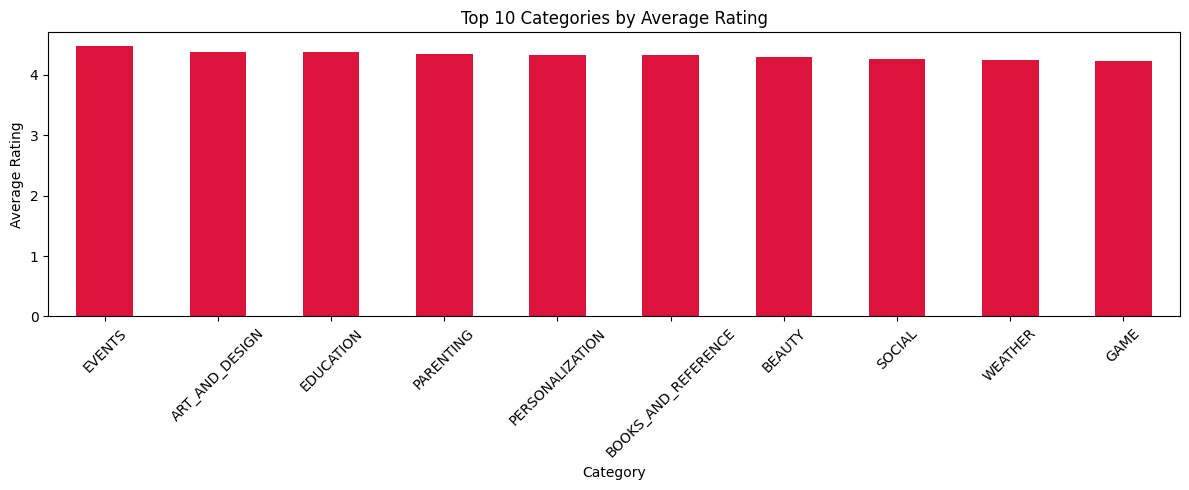

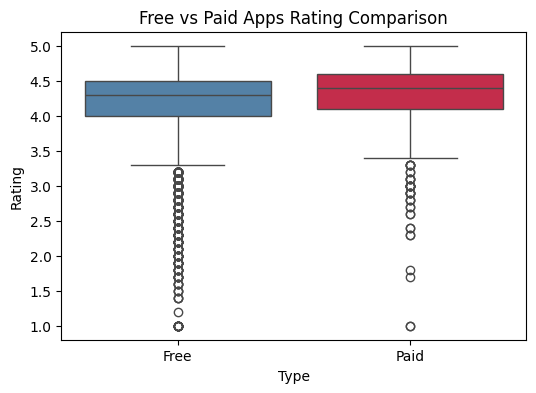

Project Complete!


In [6]:
# ================================
# Step 5 - Metrics Analysis
# ================================

# Plot 5: Top 10 Most Installed Apps
plt.figure(figsize=(12, 5))
top_installed = df_apps.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)
top_installed.plot(kind='bar', color='steelblue')
plt.title('Top 10 Categories by Total Installs')
plt.xlabel('Category')
plt.ylabel('Total Installs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 6: Average Rating by Category
plt.figure(figsize=(12, 5))
avg_rating = df_apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)
avg_rating.plot(kind='bar', color='crimson')
plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 7: Free vs Paid Rating Comparison
plt.figure(figsize=(6, 4))
sns.boxplot(x='Type', y='Rating', data=df_apps, palette=['steelblue','crimson'])
plt.title('Free vs Paid Apps Rating Comparison')
plt.show()

print("Project Complete!")
